> ### Fresh run (Cursor)
>
> 1. `cd PigeonPilot` then `pip install -e ".[dev]"` (once per venv)
> 2. If this file looks wrong: close tab **without saving**, reopen from disk
> 3. `Cmd + Shift + P` → **Jupyter: Restart Kernel and Run All Cells**


# PigeonPilot

**Research question:** Does STDP in a recurrent LIF reservoir improve path integration compared to a fixed reservoir?

Logic lives in `pigeonpilot/` (`paths` = domain, `encoding` = rate code, `curriculum` = dataset/schedule, `viz` = plots). This notebook only explains and runs it.

1. Displacement paths + curriculum  
2. Spike encoding (rate coding) — body ring → North-pointing neuron  
3. Reservoir A vs B — *next*  
4. Readout — *next*


## 1. Displacement environment

Home = `(0, 0)`. A **level** = segments `(heading, distance)`.

**Heading convention (frozen):** compass degrees — `0°` = North (`+y`), `90°` = East (`+x`), `180°` = South (`-y`), `270°` = West (`-x`).  
Unit step: `(dx, dy) = (sin θ, cos θ) * distance`. Default: 36 bins → 10°.

**Seeds:** `generate_curriculum_dataset(seed=42)` by default; `generate_level(seed=0)` (always an `int`, never `None`).

### Two naming layers (do not mix them up)

**A) Trajectory family** = *shape* of the path (`linear` / `turning` / `curved`).  
Display labels come from `STYLE_LABELS` (printed below).

**B) Difficulty tag** = *curriculum stage* (`easy` / `medium` / `hard`).  
Full counts and skills come from `DIFFICULTY_SPECS` via `format_curriculum_table()` in §1.2.

- **Displacement vector:** home → release  
- **Home vector:** release → home


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from pigeonpilot.paths import (
    STYLES,
    DIFFICULTIES,
    Segment,
    generate_level,
)
from pigeonpilot.encoding import (
    encode_level,
    heading_to_bin,
    plan_encoding,
)
from pigeonpilot.curriculum import (
    DEFAULT_EPOCHS_PER_DIFFICULTY,
    curriculum_level_count,
    format_curriculum_table,
    format_style_labels_table,
    generate_curriculum_dataset,
    split_dataset,
    summarize_dataset,
    iter_train_schedule,
)
from pigeonpilot.viz import (
    plot_level,
    plot_level_encoding,
    plot_body_ring_anatomy,
    plot_level_ring_frames,
    plot_levels_grid,
    plot_release_points,
    compute_xy_limits,
)

print("imports ok")
print("trajectory families:", STYLES)
display(Markdown("### Trajectory family labels (`STYLE_LABELS`)"))
display(Markdown(format_style_labels_table()))


imports ok
trajectory families: ('linear', 'turning', 'curved')


### Trajectory family labels (`STYLE_LABELS`)

| Name | Meaning |
|------|---------|
| `linear` | straight / direct |
| `turning` | heading jumps (turns) |
| `curved` | wave or sweeping arc |

### 1.1 One example per trajectory family

`linear` / `turning` / `curved` — shared x/y scale.


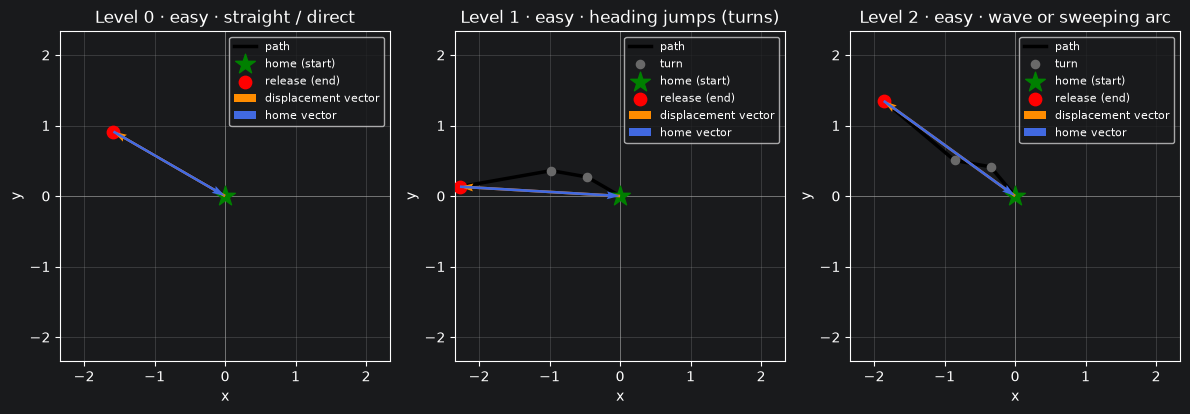

In [24]:
demo = [
    generate_level(style=s, n_segments=3, seed=0, level_id=i, turning_scale="gentle")
    for i, s in enumerate(("linear", "turning", "curved"))
]
xlim, ylim = compute_xy_limits(demo)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, level in zip(axes, demo):
    plot_level(level, ax=ax, xlim=xlim, ylim=ylim)
plt.tight_layout()
plt.show()


In [16]:
display(Markdown("### 1.2 Curriculum: difficulty tags × trajectory families"))
display(Markdown(format_curriculum_table()))
print("DEFAULT_EPOCHS_PER_DIFFICULTY:", DEFAULT_EPOCHS_PER_DIFFICULTY)


### 1.2 Curriculum: difficulty tags × trajectory families

| Difficulty | Count | Families used | Segments | Skill |
|------------|------:|---------------|----------|-------|
| **easy** | 60 | `linear` + gentle `turning` | 2–3 | distance + mild turn |
| **medium** | 60 | sharp `turning` + mild `curved` | 4–5 | many turns/curves (no linear) |
| **hard** | 30 | sharp `turning` + arc `curved` | 6–8 | long memory + circle-like arcs |

**Total = 150 levels.** Then ~80% train / ~20% test.

DEFAULT_EPOCHS_PER_DIFFICULTY: {'easy': 40, 'medium': 30, 'hard': 30}


### 1.3 Generate the full curriculum and plot them

Expected total comes from `curriculum_level_count()` (SSOT).

One figure per difficulty. Each grid zooms to that group only (square axes around home).


In [ ]:
DATASET_SEED = 42
SPLIT_SEED = 0
EXPECTED_N = curriculum_level_count()

dataset = generate_curriculum_dataset(seed=DATASET_SEED)
print(summarize_dataset(dataset))
assert len(dataset) == EXPECTED_N, f"expected {EXPECTED_N}, got {len(dataset)}"

train_set, test_set = split_dataset(dataset, train_frac=0.8, seed=SPLIT_SEED)
print(f"train: {len(train_set)} | test: {len(test_set)}")

xlim_global, ylim_global = compute_xy_limits(dataset)

for difficulty in DIFFICULTIES:
    subset = [lv for lv in dataset if lv.difficulty == difficulty]
    plot_levels_grid(subset, title=f"Difficulty: {difficulty}")
    plt.show()


{'total': 150, 'by_difficulty': {'easy': 60, 'medium': 60, 'hard': 30}, 'by_style': {'linear': 30, 'turning': 75, 'curved': 45}}
train: 120 | test: 30


### 1.4 Training order

`SCHEDULE_MODE`:

- `"curriculum"` → **easy → medium → hard** (shuffle inside each difficulty)
- `"mixed"` → shuffle all train levels every epoch

Only `train_set` is used.


In [ ]:
SCHEDULE_MODE = "curriculum"  # or "mixed"

schedule = list(
    iter_train_schedule(
        train_set,
        mode=SCHEDULE_MODE,
        epochs_per_difficulty=DEFAULT_EPOCHS_PER_DIFFICULTY,
        seed=0,
    )
)

from collections import Counter

print("mode:", SCHEDULE_MODE)
print("epochs_per_difficulty:", DEFAULT_EPOCHS_PER_DIFFICULTY)
print("presentations:", len(schedule))
print("per phase:", dict(Counter(phase for phase, *_ in schedule)))
print("first:", schedule[0][0], schedule[0][3].style, schedule[0][3].difficulty)
print("last:", schedule[-1][0], schedule[-1][3].style, schedule[-1][3].difficulty)


### 1.5 Release-point map

Each dot = path end (release). Star = home. Color = difficulty.
Uses one global window so absolute distances stay comparable.


In [ ]:
# home_xy == -end_xy is locked in unit tests

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_release_points(
    train_set, ax=axes[0], title="Train release points",
    xlim=xlim_global, ylim=ylim_global,
)
plot_release_points(
    test_set, ax=axes[1], title="Test release points",
    xlim=xlim_global, ylim=ylim_global,
)
plt.tight_layout()
plt.show()

print(f"section 1 done | {len(dataset)} levels | train {len(train_set)} | test {len(test_set)}")


---

## 2. Spike encoding (rate coding)

Section 1 built **where** the pigeon is dragged. Here we build **what its sensors fire** — still no BindsNET.

**What you will see**

1. Where **N/E/S/W** live, and all **36 bins** on the body ring  
2. Three demos: **#34** → **#42** → **#142**  
3. Segment → North-pointing bin → spike duration  
4. Per level: **path ↔ raster**, then **ring flipbook** (paired, same colors)


### 2.1 Body ring → North-pointing neuron

The pigeon always faces travel direction. Input neurons sit on a **body-fixed** ring (36 × 10°).

- Bin `0` = beak / forward (*“neuron 1”* in everyday talk — Python is 0-based)  
- Spikes go to the bin that currently points at **geographic North**  
- Face North (`0°`) → bin `0`; East (`90°`) → `27`; South (`180°`) → `18`; West (`270°`) → `9`  
- Firing **duration** ∝ distance: `n_steps = max(1, round(distance / (v · dt)))`

Read the figure left → right: fixed world compass → bins on the bird → worked example.


In [ ]:
fig = plot_body_ring_anatomy()
plt.show()


### 2.2 Three examples from the curriculum

Same dataset as §1.3 (`DATASET_SEED = 42`):

| Level | Role | Why |
|------:|------|-----|
| **#34** | warm-up | `easy` · 2 segments · starts heading `0°` → bin `0` |
| **#42** | step-up | `easy` · 3 segments · bins mid-ring |
| **#142** | main demo | `hard` · long arc · many bins around the ring |


In [ ]:
level_34 = next(lv for lv in dataset if lv.level_id == 34)
level_42 = next(lv for lv in dataset if lv.level_id == 42)
level_142 = next(lv for lv in dataset if lv.level_id == 142)
demo_levels = (level_34, level_42, level_142)

for lv in demo_levels:
    print(
        f"#{lv.level_id}  ·  {lv.difficulty}  ·  {lv.style}  ·  "
        f"{len(lv.segments)} segments"
    )

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
plot_level(level_34, ax=axes[0], title="#34 · warm-up")
plot_level(level_42, ax=axes[1], title="#42 · step-up")
plot_level(level_142, ax=axes[2], title="#142 · main")
plt.tight_layout()
plt.show()


### 2.3 Encode all three routes

`dt=0.25` makes duration bars readable (still: longer segment ⇒ longer streak). Unit tests keep `dt=1`.


In [ ]:
ENCODE_DT = 0.25
ENCODE_V = 1.0


def show_encoding(level):
    plan = plan_encoding(level.segments, velocity=ENCODE_V, dt=ENCODE_DT)
    spikes = encode_level(level, velocity=ENCODE_V, dt=ENCODE_DT)
    print(
        f"\n#{level.level_id}  shape={spikes.shape}  "
        f"active bins={sorted({b.bin_idx for b in plan})}"
    )
    print(f"{'seg':>3}  {'heading':>8}  {'bin':>4}  {'dist':>6}  {'steps':>5}  {'t_range':>12}")
    print("-" * 52)
    for i, b in enumerate(plan):
        print(
            f"{i:>3}  {b.heading_deg:>7.1f}°  {b.bin_idx:>4}  {b.distance:>6.3f}  "
            f"{b.n_steps:>5}  [{b.start:>3}, {b.end:>3})"
        )
    return plan, spikes


print(
    f"sanity: North→{heading_to_bin(0)}, East→{heading_to_bin(90)}, "
    f"South→{heading_to_bin(180)}, West→{heading_to_bin(270)}"
)
plan_34, spikes_34 = show_encoding(level_34)
plan_42, spikes_42 = show_encoding(level_42)
plan_142, spikes_142 = show_encoding(level_142)

assert heading_to_bin(0) == 0 and heading_to_bin(90) == 27
assert heading_to_bin(180) == 18 and heading_to_bin(270) == 9
assert spikes_34.shape[0] == plan_34[-1].end
assert spikes_42.shape[0] == plan_42[-1].end
assert spikes_142.shape[0] == plan_142[-1].end


### 2.4 Path, raster & ring — one level at a time

For each demo level you get the **same story twice**:

1. **Path ↔ spike raster** (shared time axis across all three)  
2. **Ring flipbook** — North fixed at top; beak + 36-bin ring rotate; highlighted bin = the neuron at North (spikes)

Colors match across path, raster, and ring frames. Order: **#34 → #42 → #142** (short flipbooks are centered).


In [ ]:
t_max = max(spikes_34.shape[0], spikes_42.shape[0], spikes_142.shape[0])
print(f"shared raster x-axis: 0 … {t_max} steps")

for lv in (level_34, level_42, level_142):
    fig = plot_level_encoding(lv, velocity=ENCODE_V, dt=ENCODE_DT, t_max=t_max)
    plt.show()

    fig = plot_level_ring_frames(lv, velocity=ENCODE_V, dt=ENCODE_DT)
    plt.show()


## 3. Reservoir A vs B *(coming next)*

## 4. Readout *(coming next)*
